# Training Vision Classifiers with PyTorch Lightning

This notebook demonstrates how to train a simple, efficient Convolutional Neural Network (CNN) with residual connections on the MNIST dataset using PyTorch Lightning. The configuration is tuned for ≥99.7% accuracy.

In [1]:
!pip install pytorch-lightning torch torchvision datasets wandb pillow scikit-learn imageio_ffmpeg bitsandbytes tsilva_notebook_utils==0.0.81

In [2]:
from PIL import ExifTags, Image
Image.ExifTags = ExifTags  # Hack to bypass broken import

Define config:

In [3]:
import os

def setup_config():
    # General Settings
    #model_id = "resnet18"#"resnet50"
    #model_id = "mobilenet_v3_small"
    #model_id = "densenet121"
    model_id = "efficientnet_b7"
    #model_id = "vit_b_16"#"vit_b_16_patch16_224"
    backbone_warmup_percentage = 0.0
    dataset_id = "cifar10"  # Options: "mnist" or "cifar10"
    pretrained_dataset_id = "imagenet"
    seed = 42
    n_epochs = 100
    batch_size = 64
    # Optimizer Settings
    learning_rate = 1e-3
    weight_decay = 0
    # Model Architecture
    nonlinearity = 'relu'
    # Data Settings
    train_size = 0.8
    val_size = 0.2
    # Softcoded new params
    label_smoothing = 0
    early_stopping_patience = 7
    early_stopping_min_delta = 1e-4
    precision = "16-mixed"
    swa_lrs = 0#1e-2
    activation = "relu"
    
    # TODO: https://docs.pytorch.org/vision/main/transforms.html#v1-or-v2
    augmentation_pipeline = [
        ("ToImage", [], dict()),
        ("RandomCrop", [], dict(size=32, padding=4)),
        ("RandomHorizontalFlip", [], dict(p=0.5)),
        ("ColorJitter", [], dict(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)),
        ('ToTensor', [], dict()),
        ("RandomErasing", [], dict(p=1.0, scale=(0.02, 0.33), ratio=(0.3, 3.3))),
    ]

    """
    transforms = v2.Compose([
        v2.ToImage(),  # Convert to tensor, only needed if you had a PIL image
        v2.ToDtype(torch.uint8, scale=True),  # optional, most input are already uint8 at this point
        # ...
        v2.RandomResizedCrop(size=(224, 224), antialias=True),  # Or Resize(antialias=True)
        # ...
        v2.ToDtype(torch.float32, scale=True),  # Normalize expects float input
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    """

    # TODO: softcode this
    os.environ["NOTEBOOK_ID"] = "mnist-cnn-pl"

    return {
        'model_id': model_id,
        "pretrained_dataset_id": pretrained_dataset_id,
        'backbone_warmup_percentage' : backbone_warmup_percentage,
        'dataset_id': dataset_id,
        'seed': seed,
        'n_epochs': n_epochs,
        'batch_size': batch_size,
        'learning_rate': learning_rate,
        'nonlinearity': nonlinearity,
        'weight_decay': weight_decay,
        'train_size': train_size,
        'val_size': val_size,
        'label_smoothing': label_smoothing,
        'early_stopping_patience': early_stopping_patience,
        'early_stopping_min_delta': early_stopping_min_delta,
        'precision': precision,
        'swa_lrs': swa_lrs,
        'activation': activation,
        'augmentation_pipeline': augmentation_pipeline
    }

CONFIG = setup_config()

Set seed for reproducibility:

In [4]:
import pytorch_lightning as pl
pl.seed_everything(CONFIG['seed'], workers=True)

Seed set to 42


42

Set matmul precision:

In [5]:
import torch
torch.set_float32_matmul_precision('high')

Login to wandb:

In [6]:
import wandb
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: tsilva to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [7]:
import os
import time
import torch
import numpy as np
from typing import Union
import pytorch_lightning as pl
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from torchvision.transforms import v2


DATASET_SPECS = {
    "imagenet": {
        "image_size": 224,
        "mean": [0.485, 0.456, 0.406],
        "std": [0.229, 0.224, 0.225]
    },
    "cifar10": {
        "image_size": 32,
        "mean": [0.4914, 0.4822, 0.4465],
        "std": [0.2023, 0.1994, 0.2010]
    },
    "mnist": {
        "image_size": 28,
        "mean": [0.1307],
        "std": [0.3081]
    }
}

class ThresholdStoppingCallback(pl.Callback):
    def __init__(self, metric, threshold):
        super().__init__()
        self.metric = metric
        self.threshold = threshold
        
    def on_train_epoch_end(self, trainer, pl_module):
        value = trainer.callback_metrics.get(self.metric)
        if value >= self.threshold:
            print(f"Stopping training as {self.metric} reached {self.threshold}")
            trainer.should_stop = True


class EpochTimeLogger(pl.Callback):
    def on_train_epoch_start(self, trainer, pl_module):
        self.epoch_start_time = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        epoch_time = time.time() - self.epoch_start_time
        if trainer.logger is not None and hasattr(trainer.logger, "experiment"):
            trainer.logger.experiment.log({"epoch_time_sec": epoch_time, "epoch": trainer.current_epoch})


class BackboneWarmupCallback(pl.Callback):
    def __init__(self, unfreeze_at: Union[float, int]):
        if isinstance(unfreeze_at, float):
            assert 0.0 < unfreeze_at < 1.0, "Percentage must be between 0 and 1."
        elif isinstance(unfreeze_at, int):
            assert unfreeze_at >= 0, "Epoch number must be non-negative."
        else:
            raise TypeError("`unfreeze_at` must be a float (percentage) or an int (epoch number).")
        
        self.unfreeze_at = unfreeze_at
        self.unfrozen = False
        self.unfreeze_epoch = None

    def on_train_start(self, trainer, pl_module):
        if isinstance(self.unfreeze_at, float):
            self.unfreeze_epoch = int(self.unfreeze_at * trainer.max_epochs)
        else:
            self.unfreeze_epoch = self.unfreeze_at

    def on_train_epoch_start(self, trainer, pl_module):
        if self.unfrozen:
            return

        if trainer.current_epoch == 0:
            print(f"[Epoch {trainer.current_epoch}] Training with frozen backbone until epoch {self.unfreeze_epoch}...")
            pl_module.freeze_backbone()
        elif trainer.current_epoch >= self.unfreeze_epoch:
            print(f"[Epoch {trainer.current_epoch}] Unfroze backbone... now training all layers.")
            pl_module.unfreeze_backbone()
            self.unfrozen = True


def build_dataset_transforms(dataset_id: str, augmentation_pipeline: list = [], pretrained_dataset_id: str = None) -> tuple:
    assert dataset_id in DATASET_SPECS, f"Unknown dataset spec: {dataset_id}"
    
    dataset_spec = DATASET_SPECS[dataset_id]
    pretrained_dataset_spec = DATASET_SPECS.get(pretrained_dataset_id, dataset_spec)

    dataset_image_size = dataset_spec["image_size"]
    pretrained_image_dataset_size = pretrained_dataset_spec["image_size"]
    assert dataset_image_size <= pretrained_image_dataset_size, f"Dataset size {dataset_image_size} must be less than or equal to pretrained dataset size {pretrained_image_dataset_size}"

    preprocessing_pipeline = []
    if dataset_image_size < pretrained_image_dataset_size:
        crop_fraction = 0.875
        resize_size = int(round(pretrained_image_dataset_size / crop_fraction))
        preprocessing_pipeline = [
            v2.Resize(resize_size),
            v2.CenterCrop(pretrained_image_dataset_size)
        ]
    
    _augmentation_pipeline = []
    for name, args, kwargs in augmentation_pipeline:
        _class = getattr(v2, name, None)
        augmentation_fn = _class(*args, **kwargs)
        _augmentation_pipeline.append(augmentation_fn)

    normalization_pipeline = [
        v2.ToTensor(),
        v2.Normalize(mean=pretrained_dataset_spec["mean"], std=pretrained_dataset_spec["std"])
    ]
        
    transform = v2.Compose(
        preprocessing_pipeline + _augmentation_pipeline + normalization_pipeline
    )

    return transform


class BaseDataModule(pl.LightningDataModule):
    DatasetClass = None  # To be set by subclasses

    def __init__(
        self, 
        batch_size, 
        train_size, 
        seed, 
        train_shuffle=True,
        train_pin_memory=True,
        train_n_workers=8,
        train_persistent_workers=True,
        val_shuffle=False,
        val_pin_memory=True,
        val_n_workers=4,
        test_shuffle=False,
        test_pin_memory=False,
        test_n_workers=2,
        augmentation_pipeline=[],
        pretrained_dataset_id=None
    ):
        super().__init__()
        assert self.DatasetClass is not None, "DatasetClass must be set in subclass"
        self.dataset_id = self.DatasetClass.__name__.lower().replace("dataset", "")
        self.download_path = f"./temp/{self.dataset_id}"
        self.batch_size = batch_size
        self.train_size = train_size
        self.seed = seed
        
        # Split-specific args (default to base if None)
        self.train_shuffle = train_shuffle
        self.train_pin_memory = train_pin_memory
        self.train_n_workers = train_n_workers
        self.train_persistent_workers = train_persistent_workers
        
        # Set val/test shuffle default to False if not provided
        self.val_shuffle = False if val_shuffle is None else val_shuffle
        self.val_pin_memory = val_pin_memory
        self.val_n_workers = val_n_workers
        self.test_shuffle = False if test_shuffle is None else test_shuffle
        self.test_pin_memory = test_pin_memory
        self.test_n_workers = test_n_workers

        self.augmentation_pipeline = augmentation_pipeline
        self.pretrained_dataset_id = pretrained_dataset_id
        self.class_names = None
        
        self._train_transform = build_dataset_transforms(self.dataset_id, self.augmentation_pipeline, pretrained_dataset_id=self.pretrained_dataset_id)
        self._test_transform = build_dataset_transforms(self.dataset_id, [], pretrained_dataset_id=self.pretrained_dataset_id)
        self.transforms = {
            "train": lambda *args, **kwargs: self._train_transform(*args, **kwargs),
            "test": lambda *args, **kwargs: self._test_transform(*args, **kwargs)
        }

    def prepare_data(self):
        self.DatasetClass(root=self.download_path, train=True, download=True)
        self.DatasetClass(root=self.download_path, train=False, download=True)

    def setup(self, stage=None):
        if stage is None or stage == "fit":
            full = self.DatasetClass(root=self.download_path, train=True, transform=self.transforms['train'])
            self.class_names = list(full.classes)
            total = len(full)
            train_size = int(total * self.train_size)
            val_size = total - train_size
            self.train_set, self.val_set = torch.utils.data.random_split(
                full, [train_size, val_size], generator=torch.Generator().manual_seed(self.seed)
            )
            self.val_set.dataset.transform = self.transforms['test']

        if stage is None or stage == "test":
            self.test_set = self.DatasetClass(root=self.download_path, train=False, transform=self.transforms['test'])

    def train_dataloader(self, **kwargs):
        return DataLoader(
            self.train_set, 
            batch_size=self.batch_size, 
            shuffle=self.train_shuffle, 
            num_workers=self.train_n_workers,
            persistent_workers=self.train_persistent_workers,
            pin_memory=self.train_pin_memory,
            **kwargs
        )

    def val_dataloader(self, **kwargs):
        return DataLoader(
            self.val_set, 
            batch_size=self.batch_size, 
            shuffle=self.val_shuffle, 
            num_workers=self.val_n_workers,
            pin_memory=self.val_pin_memory,
            **kwargs
        )

    def test_dataloader(self, **kwargs):
        return DataLoader(
            self.test_set, 
            batch_size=self.batch_size, 
            shuffle=self.test_shuffle, 
            num_workers=self.test_n_workers,
            pin_memory=self.test_pin_memory,
            **kwargs
        )

    def _get_split_dataset(self, split):
        if split == 'train':
            return self.train_set
        elif split == 'val':
            return self.val_set
        elif split == 'test':
            return self.test_set
        else:
            raise ValueError("split must be 'train', 'val', or 'test'")

    def get_classwise_dataloader(self, n_samples_per_class=5, split='train', num_workers=2, **kwargs):
        """
        Fast version: Use underlying dataset targets to avoid loading images during sampling.
        """
        dataset = self._get_split_dataset(split)

        # Access raw dataset
        if isinstance(dataset, torch.utils.data.Subset):
            base_dataset = dataset.dataset
            subset_indices = dataset.indices
        else:
            base_dataset = dataset
            subset_indices = list(range(len(dataset)))

        # Try to use the raw targets without loading each item
        targets = (
            np.array(base_dataset.targets)
            if hasattr(base_dataset, 'targets')
            else np.array([base_dataset[i][1] for i in range(len(base_dataset))])  # fallback
        )

        class_to_indices = {i: [] for i in range(len(self.class_names))}
        shuffle_indices = np.random.permutation(len(subset_indices))
        for idx in subset_indices:
            label = targets[idx]
            if len(class_to_indices[label]) < n_samples_per_class:
                class_to_indices[label].append(idx)
            if all(len(v) >= n_samples_per_class for v in class_to_indices.values()):
                break

        final_indices = [i for indices in class_to_indices.values() for i in indices]
        subset = torch.utils.data.Subset(base_dataset, final_indices)
        #subset.dataset.transform = self.transforms['train']
        return DataLoader(subset, batch_size=self.batch_size, shuffle=False, num_workers=num_workers, **kwargs)

    class _NoAugmentations:
        def __init__(self, outer, filter=None):
            self.outer = outer
            self.filter = filter
            self.prev_train_transform = None
            self.prev_test_transform = None

        def __enter__(self):
            self.prev_train_transform = self.outer._train_transform
            self.prev_test_transform = self.outer._test_transform
            self.outer._train_transform = v2.Compose([x for x in self.outer._train_transform.transforms if self.filter(x)]) if self.filter else v2.ToTensor()
            self.outer._test_transform = v2.Compose([x for x in self.outer._test_transform.transforms if self.filter(x)]) if self.filter else v2.ToTensor()

        def __exit__(self, exc_type, exc_val, exc_tb):
            self.outer._train_transform = self.prev_train_transform
            self.outer._test_transform = self.prev_test_transform
            self.prev_train_transform = None
            self.prev_test_transform = None

    def no_augmentations(self, *args, **kwargs):
        return self._NoAugmentations(self, *args, **kwargs)


class MNISTDataModule(BaseDataModule):
    DatasetClass = MNIST

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.dataset_id = "mnist"
        self.download_path = f"./temp/{self.dataset_id}"


class CIFAR10DataModule(BaseDataModule):
    DatasetClass = CIFAR10

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.dataset_id = "cifar10"
        self.download_path = f"./temp/{self.dataset_id}"


def create_data_module(config, **kwargs):
    dataset_id = config['dataset_id']
    dataset_modules = {
        "mnist": MNISTDataModule,
        "cifar10": CIFAR10DataModule
    }
    dataset_id = dataset_id.lower()
    datamodule_class = dataset_modules.get(dataset_id)
    assert datamodule_class is not None, f"Unsupported dataset: {dataset_id}"
    datamodule = datamodule_class(**{
        "seed": config['seed'],
        "batch_size": config['batch_size'],
        "train_size": config['train_size'],
        "augmentation_pipeline": config.get('augmentation_pipeline', []),
        "pretrained_dataset_id": config.get('pretrained_dataset_id', None),
        **kwargs
    })
    datamodule.prepare_data()
    return datamodule


# TODO: provide dataloader as param
def render_samples_per_class(dm, n_samples=5, split='train'):
    """
    Show `n_samples` random images for each class from a classification dataset,
    using class-wise sampling.

    Args:
        dm: A Lightning DataModule with train/val/test dataloaders and:
            - .class_names: list of class names
            - .mean and .std: for unnormalizing images (optional)
            - .get_classwise_dataloader(n_samples_per_class, split): custom method
        n_samples: Number of images per class to show
        split: 'train', 'val', or 'test'
    """
    # Get class names
    class_names = getattr(dm, 'class_names', None)
    if class_names is None:
        raise ValueError("DataModule must define `class_names` for this function to work.")
    n_classes = len(class_names)

    # Use classwise dataloader
    loader = dm.get_classwise_dataloader(n_samples_per_class=n_samples, split=split, num_workers=4)

    # Collect samples
    images_per_class = {i: [] for i in range(n_classes)}
    for batch in loader:
        x, y = batch
        for img, label in zip(x, y):
            label = int(label)
            if len(images_per_class[label]) < n_samples:
                images_per_class[label].append(img)

    # Plotting
    fig, axes = plt.subplots(n_classes, n_samples, figsize=(n_samples * 2, n_classes * 2))

    for class_idx in range(n_classes):
        for j in range(n_samples):
            ax = axes[class_idx, j] if n_classes > 1 else axes[j]
            if len(images_per_class[class_idx]) <= j:
                ax.axis('off')
                continue

            img = images_per_class[class_idx][j]
            img = img.permute(1, 2, 0).cpu().numpy()
            img = np.clip(img, 0, 1)

            ax.imshow(img, interpolation='nearest')

            # Dynamically compute tick locations based on image size
            height, width = img.shape[:2]
            tick_step = max(1, width // 8)
            xticks = np.arange(0, width + 1, tick_step)
            yticks = np.arange(0, height + 1, tick_step)

            ax.set_xticks(xticks)
            ax.set_yticks(yticks)

            # Y tick labels always
            ax.set_yticklabels([str(t) for t in yticks])

            # X tick labels only on last row
            if class_idx == n_classes - 1:
                ax.set_xticklabels([str(t) for t in xticks])

            ax.tick_params(labelsize=6)
            ax.grid(color='gray', linestyle='--', linewidth=0.5)

            # Left column: class name
            if j == 0:
                ax.set_ylabel(class_names[class_idx], fontsize=10, rotation=90, labelpad=10)
            else:
                ax.set_yticklabels([])

    plt.tight_layout()
    return plt


Create the data module:

In [8]:
#from tsilva_notebook_utils.lightning import create_data_module
dm = create_data_module(CONFIG)
dm.setup()

/home/tsilva/miniconda3/envs/aiml-notebooks/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Files already downloaded and verified
Files already downloaded and verified


Files already downloaded and verified
Files already downloaded and verified


<module 'matplotlib.pyplot' from '/home/tsilva/miniconda3/envs/aiml-notebooks/lib/python3.11/site-packages/matplotlib/pyplot.py'>

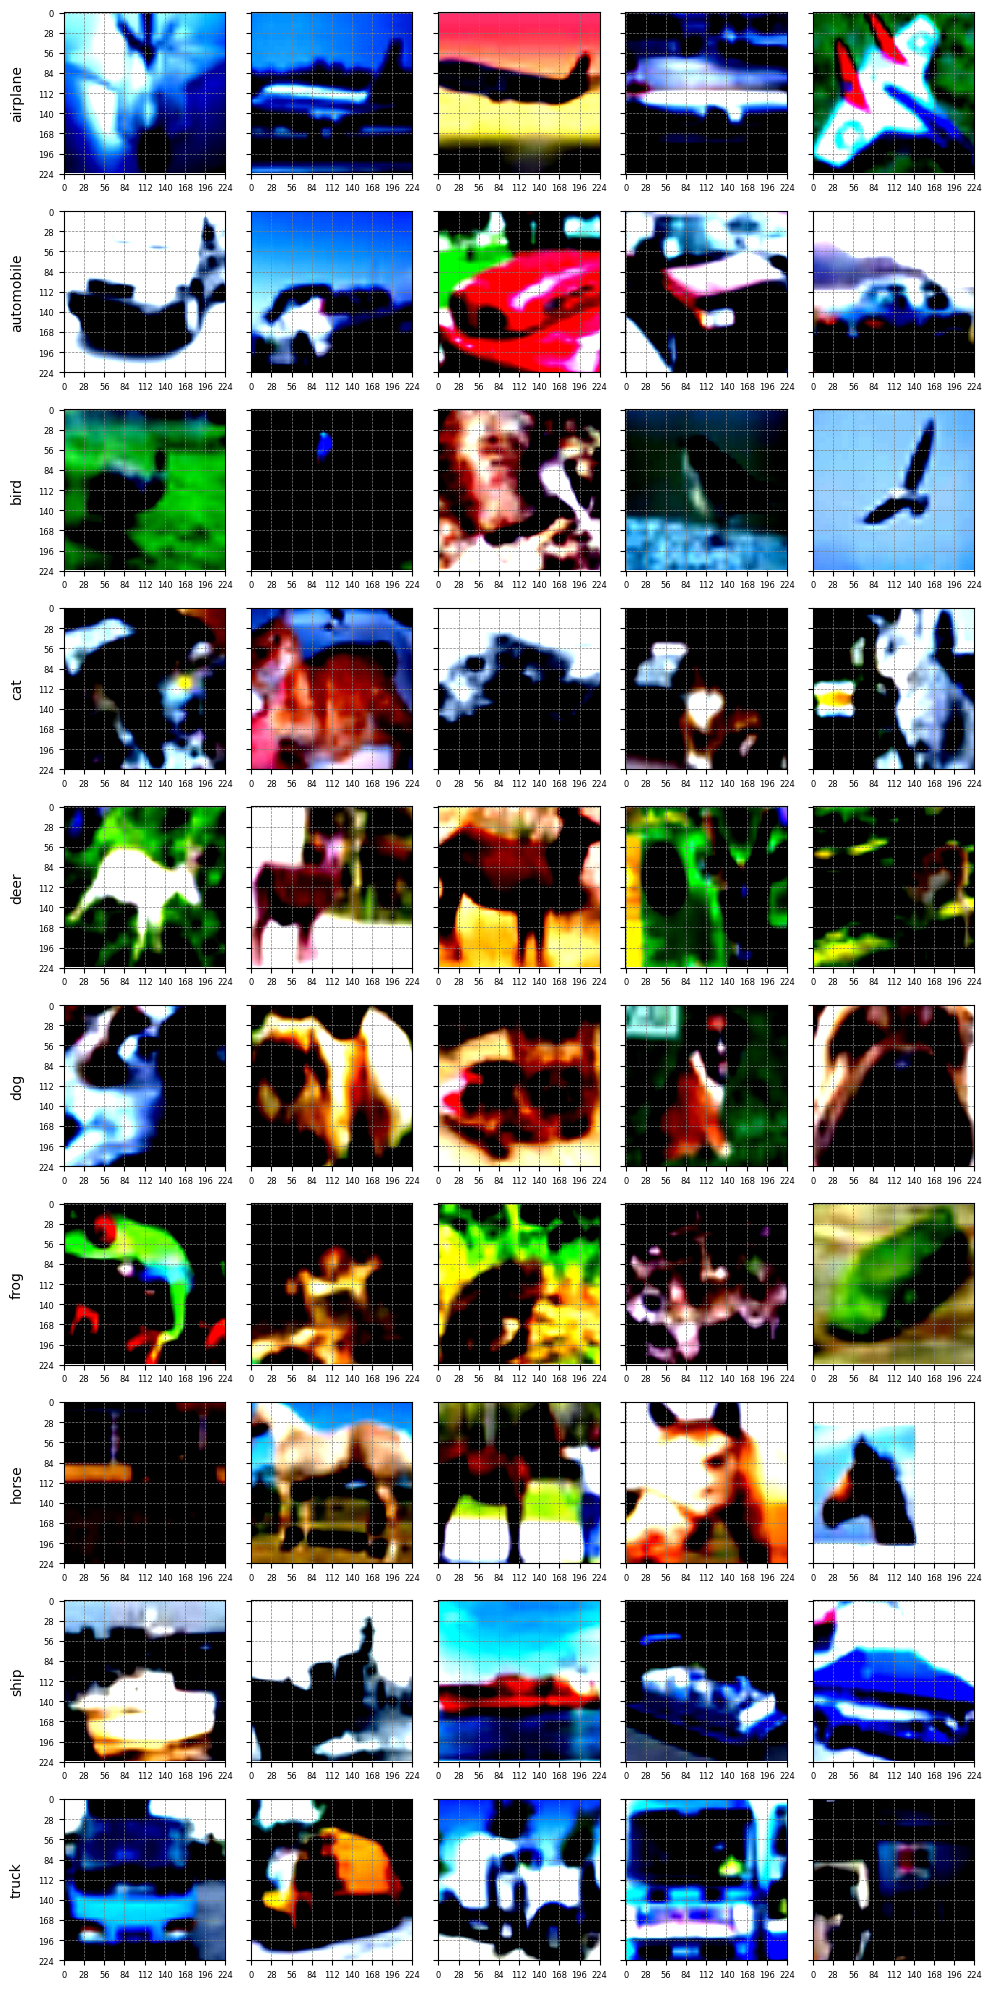

In [9]:
from tsilva_notebook_utils.lightning import render_samples_per_class

dm = create_data_module(CONFIG)
dm.setup()
render_samples_per_class(dm, n_samples=5, split='train')

In [10]:
from tsilva_notebook_utils.video import render_video_from_batches
from torchvision.transforms import v2

dm = create_data_module(CONFIG)
dm.setup()
skip_normalize_fn=lambda x: x if not isinstance(x, v2.Normalize) else None
with dm.no_augmentations(filter=skip_normalize_fn): video = render_video_from_batches(next(iter(dm.train_dataloader()))[0], scale=1, fps=1)
video

/home/tsilva/miniconda3/envs/aiml-notebooks/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Files already downloaded and verified
Files already downloaded and verified


In [11]:
torch.hub.load("pytorch/vision", CONFIG["model_id"], weights="DEFAULT")

Using cache found in /home/tsilva/.cache/torch/hub/pytorch_vision_main


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
            (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormAct

Create the model:

In [ ]:
from torch import nn

class LitModel(pl.LightningModule):
    def __init__(self, lr=None, n_classes=None):
        super().__init__()

        self.save_hyperparameters()

        assert n_classes is not None, "n_classes must be provided"
        
        # Load model from torch hub
        self.model = torch.hub.load("pytorch/vision", CONFIG["model_id"], weights="DEFAULT")

        # Swap out classification head (eg: pretrained weights may have different number of classes)
        self.replace_last_linear_generic(n_classes) # TODO: remove last layer instead?

        self.criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG['label_smoothing'])
    
    def get_last_linear(self):
        last = None
        for m in self.model.modules():
            if isinstance(m, nn.Linear):
                last = m
        if last is None:
            raise ValueError("No nn.Linear layer found.")
        return last
    
    def find_last_sequential(self, module):
        last_seq = None
        for child in module.children():
            if isinstance(child, nn.Sequential):
                last_seq = child
            seq_in_child = self.find_last_sequential(child)
            if seq_in_child is not None:
                last_seq = seq_in_child
        return last_seq

    def replace_last_linear_in_sequential(self, seq, out_features):
        idx = None
        for i, m in reversed(list(enumerate(seq))):
            if isinstance(m, nn.Linear):
                idx = i
                break
        if idx is None:
            raise ValueError("No nn.Linear layer found in Sequential.")
        in_features = seq[idx].in_features
        seq[idx] = nn.Linear(in_features, out_features)
        return seq

    def replace_last_linear_generic(self, out_features):
        seq = self.find_last_sequential(self.model)
        if seq is not None:
            self.replace_last_linear_in_sequential(seq, out_features)
        else:
            self.replace_last_linear(out_features)


    def freeze_backbone(self):
        head = self.get_last_linear()
        for param in self.model.parameters(): param.requires_grad = False
        for param in head.parameters(): param.requires_grad = True

    def unfreeze_backbone(self):
        head = self.get_last_linear()
        for param in self.model.parameters(): param.requires_grad = True
        for param in head.parameters(): param.requires_grad = True

    def forward(self, x):
        x = self.model(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train/loss", loss, prog_bar=True)
        self.log("train/acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = logits.argmax(dim=1)
        acc = (preds == y).float().mean()
        self.log("val/loss", loss, prog_bar=True, sync_dist=True)
        self.log("val/acc", acc, prog_bar=True, sync_dist=True)
        return {}

    def on_validation_epoch_end(self):
        pass

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("test/loss", loss)
        self.log("test/acc", acc)

    def configure_optimizers(self):
        import bitsandbytes as bnb

        optimizer = bnb.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=CONFIG['weight_decay'],
            optim_bits=8
            # Optionally: set optim_bits=8 for 8-bit optimizer
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=2
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val/loss",
                "interval": "epoch",
                "frequency": 1
            }
        }

model = LitModel(
    lr=CONFIG['learning_rate'],
    n_classes=len(dm.class_names)
)
model

Using cache found in /home/tsilva/.cache/torch/hub/pytorch_vision_main


TypeError: LitModel.replace_last_linear_in_sequential() takes 2 positional arguments but 3 were given

Find optimal batch size:

In [ ]:
#from pytorch_lightning.tuner import Tuner
#trainer = pl.Trainer()
#tuner = Tuner(trainer)
#tuner.scale_batch_size(model, datamodule=dm, mode="power")

First try to overfit a batch to make sure the training pipeline works:

In [ ]:
from tsilva_notebook_utils.lightning import ThresholdStoppingCallback

trainer = pl.Trainer(
    log_every_n_steps=1,
    overfit_batches=1,
    max_epochs=100,
    callbacks=[ThresholdStoppingCallback("train/acc", 1.0)]
)
model = LitModel(
    lr=CONFIG['learning_rate'],
    n_classes=len(dm.class_names)
)
trainer.fit(model, datamodule=create_data_module(CONFIG, batch_size=32, train_shuffle=False))

Run the training loop:

In [ ]:
from tsilva_notebook_utils.lightning import EpochTimeLogger, BackboneWarmupCallback
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.callbacks import StochasticWeightAveraging
from pytorch_lightning.profilers import SimpleProfiler

profiler = SimpleProfiler(dirpath=".", filename="profiler_output.txt")

num_gpus = torch.cuda.device_count()
trainer = pl.Trainer(
    devices=num_gpus,
    accelerator="auto", # TODO: is this default?
    strategy="auto", # TODO: is this default?
    benchmark=True,
    max_epochs=CONFIG['n_epochs'],
    log_every_n_steps=5,
    logger=WandbLogger(project=os.environ["NOTEBOOK_ID"], config=CONFIG),
    precision=CONFIG['precision'],
    #profiler="simple",
    #enable_progress_bar=True,
    #enable_model_summary=True,
    # TODO: add callback factory to tsilva_notebook_utils
    callbacks=[x for x in [
        EpochTimeLogger(), 
        LearningRateMonitor(logging_interval="epoch"),
        EarlyStopping(
            monitor="val/loss",
            patience=CONFIG['early_stopping_patience'],
            min_delta=CONFIG['early_stopping_min_delta'],
            mode="min",
            verbose=True,
            strict=True
        ) if CONFIG['early_stopping_patience'] > 0 else None,
        StochasticWeightAveraging(swa_lrs=CONFIG['swa_lrs']) if CONFIG['swa_lrs'] > 0 else None,
        BackboneWarmupCallback(CONFIG['backbone_warmup_percentage']) if CONFIG['backbone_warmup_percentage'] > 0 else None
    ] if x is not None]
)
model = LitModel(
    lr=CONFIG['learning_rate'],
    n_classes=len(dm.class_names)
)
trainer.fit(model, datamodule=dm)


Validation: |          | 0/? [00:00<?, ?it/s]

Calculate the post-training test set accuracy:

In [ ]:
single_gpu_trainer = pl.Trainer(
    devices=1,
    accelerator="auto"
)
single_gpu_trainer.test(model, datamodule=dm)